Задание. Получить 4 состояния Белла

In [1]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit import Aer, assemble
from qiskit import execute, BasicAer

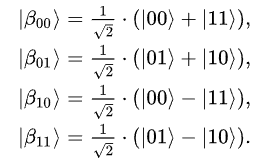

In [2]:
# Для 00

backend = BasicAer.get_backend('qasm_simulator')
q = QuantumRegister(2)
c = ClassicalRegister(2)
circuit = QuantumCircuit(q, c)

circuit.barrier()

circuit.h(0)
circuit.cx(0,1)

print(circuit)

circuit.measure(q, c)
result = execute(circuit, backend, shots=10000).result()
print(result.get_counts())

       ░ ┌───┐     
q0_0: ─░─┤ H ├──■──
       ░ └───┘┌─┴─┐
q0_1: ─░──────┤ X ├
       ░      └───┘
c0_0: ═════════════
                   
c0_1: ═════════════
                   
{'00': 4951, '11': 5049}


In [3]:
# Для 10
backend = BasicAer.get_backend('qasm_simulator')
q = QuantumRegister(2)
c = ClassicalRegister(2)
circuit = QuantumCircuit(q, c)

circuit.x(0)

circuit.barrier()

circuit.h(0)
circuit.cx(0,1)

print(circuit)

circuit.measure(q, c)
result = execute(circuit, backend, shots=10000).result()
print(result.get_counts())

      ┌───┐ ░ ┌───┐     
q5_0: ┤ X ├─░─┤ H ├──■──
      └───┘ ░ └───┘┌─┴─┐
q5_1: ──────░──────┤ X ├
            ░      └───┘
c1_0: ══════════════════
                        
c1_1: ══════════════════
                        
{'11': 5008, '00': 4992}


In [4]:
# Для 11
backend = BasicAer.get_backend('qasm_simulator')
q = QuantumRegister(2)
c = ClassicalRegister(2)
circuit = QuantumCircuit(q, c)

circuit.x(0)
circuit.x(1)
circuit.barrier()

circuit.h(0)
circuit.cx(0,1)

print(circuit)

circuit.measure(q, c)
result = execute(circuit, backend, shots=10000).result()
print(result.get_counts())

       ┌───┐ ░ ┌───┐     
q11_0: ┤ X ├─░─┤ H ├──■──
       ├───┤ ░ └───┘┌─┴─┐
q11_1: ┤ X ├─░──────┤ X ├
       └───┘ ░      └───┘
 c2_0: ══════════════════
                         
 c2_1: ══════════════════
                         
{'01': 5057, '10': 4943}


In [5]:
# Для 01
backend = BasicAer.get_backend('qasm_simulator')
q = QuantumRegister(2)
c = ClassicalRegister(2)
circuit = QuantumCircuit(q, c)


circuit.x(1)
circuit.barrier()

circuit.h(0)
circuit.cx(0,1)

print(circuit)

circuit.measure(q, c)
result = execute(circuit, backend, shots=10000).result()
print(result.get_counts())

             ░ ┌───┐     
q17_0: ──────░─┤ H ├──■──
       ┌───┐ ░ └───┘┌─┴─┐
q17_1: ┤ X ├─░──────┤ X ├
       └───┘ ░      └───┘
 c3_0: ══════════════════
                         
 c3_1: ══════════════════
                         
{'01': 4940, '10': 5060}


Задание 5. Квантовая телепортация

In [6]:

qr = QuantumRegister(3, name="q")
crz = ClassicalRegister(1, name="crz")
crx = ClassicalRegister(1, name="crx")

qc = QuantumCircuit(qr, crz, crx)

qc.h(qr[1])
qc.cx(qr[1], qr[2])
qc.cx(qr[0], qr[1])
qc.h(qr[0])

qc.measure(qr[0], crz)
qc.measure(qr[1], crx)
qc.x(qr[2]).c_if(crx, 1)
qc.z(qr[2]).c_if(crz, 1)

qc.draw()

┌───┐┌─┐          
q_0: ────────────■──┤ H ├┤M├──────────
     ┌───┐     ┌─┴─┐└┬─┬┘└╥┘          
q_1: ┤ H ├──■──┤ X ├─┤M├──╫───────────
     └───┘┌─┴─┐└───┘ └╥┘  ║ ┌───┐┌───┐
q_2: ─────┤ X ├───────╫───╫─┤ X ├┤ Z ├
          └───┘       ║   ║ └─╥─┘└─╥─┘
crz: ═════════════════╬═══╩═══╬════■══
                      ║       ║   0x1 
crx: ═════════════════╩═══════■═══════
                             0x1

Задание 6. Классические логические операторы

In [7]:
# Оператор NOT
def NOT(inp):
    qc = QuantumCircuit(1, 1) 
    qc.reset(0)
    if inp=='1':
        qc.x(0)
    qc.barrier()
    qc.x(0)
    qc.barrier()
    qc.measure(0,0)
    backend = Aer.get_backend('aer_simulator')
    job = backend.run(qc, shots=1, memory=True)
    output = job.result().get_memory()[0]
    
    return qc, output

In [8]:
for inp in ['0', '1']:
    qc, out = NOT(inp)
    print('NOT with input',inp,'gives output',out)


NOT with input 0 gives output 1
NOT with input 1 gives output 0


In [58]:
# Оператор OR
def OR(inp1,inp2):

    qc = QuantumCircuit(2, 1) 
    qc.reset(range(2))
    
    if inp1=='1':
        qc.x(0)
    if inp2=='1':
        qc.x(1)

    qc.barrier()
    qc.barrier()
    qc.measure(1, 0) 
    backend = Aer.get_backend('aer_simulator')
    job = backend.run(qc,shots=1,memory=True)
    output = job.result().get_memory()[0]
  
    return qc, output

In [59]:
for inp1 in ['0', '1']:
    for inp2 in ['0', '1']:
        qc, output = OR(inp1, inp2)
        print('OR with inputs',inp1,inp2,'gives output',output)
# тут что то пошло не так

OR with inputs 0 0 gives output 0
OR with inputs 0 1 gives output 1
OR with inputs 1 0 gives output 0
OR with inputs 1 1 gives output 1


In [50]:
# Оператор AND
def AND(inp1,inp2):

    qc = QuantumCircuit(2, 1) 
    qc.reset(range(1))
  
    if inp1=='1':
        qc.x(0)
        if inp2=='1':
            qc.x(1)
        
    qc.barrier()

    qc.barrier()
    qc.measure(1, 0) 
  
    backend = Aer.get_backend('aer_simulator')

    job = backend.run(qc, shots=1, memory=True)
    output = job.result().get_memory()[0]
  
    return qc, output

In [51]:
for inp1 in ['0', '1']:
    for inp2 in ['0', '1']:
        qc, output = AND(inp1, inp2)
        print('AND with inputs',inp1,inp2,'gives output',output)


AND with inputs 0 0 gives output 0
AND with inputs 0 1 gives output 0
AND with inputs 1 0 gives output 0
AND with inputs 1 1 gives output 1


In [54]:
# Оператор XOR
def XOR(inp1,inp2):
  
    qc = QuantumCircuit(2, 1) 
    qc.reset(range(2))
    
    if inp1=='1':
        qc.x(0)
    if inp2=='1':
            qc.x(1)

    qc.barrier()

    qc.barrier()
    
    qc.measure(1,0) 

    backend = Aer.get_backend('aer_simulator')
    job = backend.run(qc, shots=1, memory=True)
    output = job.result().get_memory()[0]
  
    return qc, output

In [55]:
for inp1 in ['0', '1']:
    for inp2 in ['0', '1']:
        qc, output = XOR(inp1, inp2)
        print('XOR with inputs',inp1,inp2,'gives output',output)

XOR with inputs 0 0 gives output 0
XOR with inputs 0 1 gives output 1
XOR with inputs 1 0 gives output 0
XOR with inputs 1 1 gives output 1


In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit import Aer, assemble
from qiskit import execute, BasicAer
import numpy as np

Алгоритм Дойча в первоначальном варианте с оператором X

In [ ]:
def dj_oracle(case, n):
    oracle_qc = QuantumCircuit(n+1)
    if case == "balanced":
        b = np.random.randint(1,2**n)
        b_str = format(b, '0'+str(n)+'b')
        for qubit in range(len(b_str)):
            if b_str[qubit] == '1':
                oracle_qc.x(qubit)
        for qubit in range(n):
            oracle_qc.cx(qubit, n)
        for qubit in range(len(b_str)):
            if b_str[qubit] == '1':
                oracle_qc.x(qubit)
    if case == "constant":
        output = np.random.randint(2)
        if output == 1:
            oracle_qc.x(n)
    
    oracle_gate = oracle_qc.to_gate()
    oracle_gate.name = "Oracle" 
    return oracle_gate

In [ ]:
def dj_algorithm(oracle, n):
    dj_circuit = QuantumCircuit(n+1, n)
    dj_circuit.x(n)
    dj_circuit.h(n)

    for qubit in range(n):
        dj_circuit.h(qubit)

    dj_circuit.append(oracle, range(n+1))

    for qubit in range(n):
        dj_circuit.h(qubit)
    
    for i in range(n):
        dj_circuit.measure(i, i)
    
    return dj_circuit

In [ ]:
n = 1
oracle_gate = dj_oracle('balanced', n)
dj_circuit = dj_algorithm(oracle_gate, n)
dj_circuit.draw()

In [ ]:
dj_circuit.measure(1,0)
backend = BasicAer.get_backend('qasm_simulator')
result = execute(dj_circuit, backend, shots=10000).result()
print(result.get_counts())

C заменой на оператор Y

In [ ]:
def dj_algorithm(oracle, n):
    dj_circuit = QuantumCircuit(n+1, n)
    dj_circuit.y(n)
    dj_circuit.h(n)

    for qubit in range(n):
        dj_circuit.h(qubit)

    dj_circuit.append(oracle, range(n+1))

    for qubit in range(n):
        dj_circuit.h(qubit)
    
    for i in range(n):
        dj_circuit.measure(i, i)
    
    return dj_circuit

In [ ]:
n = 1
oracle_gate = dj_oracle('balanced', n)
dj_circuit = dj_algorithm(oracle_gate, n)
dj_circuit.draw()

In [ ]:
dj_circuit.measure(1,0)
backend = BasicAer.get_backend('qasm_simulator')
result = execute(dj_circuit, backend, shots=10000).result()
print(result.get_counts())

C заменой на оператор CNOT

In [ ]:
def dj_algorithm(oracle, n):
    dj_circuit = QuantumCircuit(n+1, n)
    dj_circuit.y(n)
    dj_circuit.cx(n,0)

    for qubit in range(n):
        dj_circuit.h(qubit)

    dj_circuit.append(oracle, range(n+1))

    for qubit in range(n):
        dj_circuit.h(qubit)
    
    for i in range(n):
        dj_circuit.measure(i, i)
    
    return dj_circuit

In [ ]:
n = 1
oracle_gate = dj_oracle('balanced', n)
dj_circuit = dj_algorithm(oracle_gate, n)
dj_circuit.draw()